In [1]:
from pykawa.cross_sections import CrossSection, CrossSectionInterpolator
from pykawa.utils import get_phases
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from importlib.resources import files

def make_cross_section_interpolator(potential, cross_section_type='VISCOSITY',
                                    v=None, v_power=4.0):
    """
    Build a CrossSectionInterpolator from the precomputed phase shift data
    for a given potential.

    Parameters
    ----------
    potential : str
        Either 'ATTRACTIVE_YUKAWA' or 'REPULSIVE_YUKAWA'.
    cross_section_type : str, optional
        One of 'VISCOSITY', 'MOMENTUM', or 'TOTAL'. Default is 'VISCOSITY'.
    v : ndarray, optional
        Velocity array in km/s at which to evaluate the cross section.
        Defaults to np.logspace(-1, 4, 100).
    v_power : float, optional
        Power law index for high-velocity extrapolation. Default is 4.0.

    Returns
    -------
    CrossSectionInterpolator
    """
    if v is None:
        v = np.logspace(-1, 4, 100)
    
    scale = 10 if potential == 'REPULSIVE_YUKAWA' else 100
    data = np.load(files("pykawa.data").joinpath(f"{potential}_phases.npz"))
    mphi_vals  = data["mphi"]
    alpha_vals = data["alpha"]

    log10_mass_ratio_values = mphi_vals / scale
    log10alpha_values       = -alpha_vals / scale
    print(log10_mass_ratio_values)
    print(log10alpha_values)
    n_alpha = len(log10alpha_values)
    n_mr    = len(log10_mass_ratio_values)
    cross_section_table = np.empty((n_alpha, n_mr, len(v)))
    v_grid_table = np.empty((n_alpha, n_mr, 25))
    
    for i, log10alpha in enumerate(log10alpha_values):
        for j, log10_mass_ratio in enumerate(log10_mass_ratio_values):
            v_grid, phases = get_phases(log10_mass_ratio, log10alpha, potential)
            cross = CrossSection.from_phase_shifts(
                v_grid, phases,  # v_grid is already log10(v)
                cross_section_type, log10alpha, log10_mass_ratio,
                v_power=v_power
                    )
            cross_section_table[i, j, :] = cross(v, None)
            v_grid_table[i, j, :] = v_grid
    cross_section_interpolator = CrossSectionInterpolator(v, log10alpha_values, log10_mass_ratio_values,
                                    cross_section_table)
    return cross_section_interpolator, cross_section_table, log10_mass_ratio_values, log10alpha_values, v_grid_table

cross_section_interpolator, cross_section_table, log10_mass_ratio_values, log10alpha_values, v_grid_table = make_cross_section_interpolator('REPULSIVE_YUKAWA')

[2.8 3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2]
[-2.  -2.3 -2.6 -2.9 -3.2 -3.5 -3.8 -4.1 -4.4]


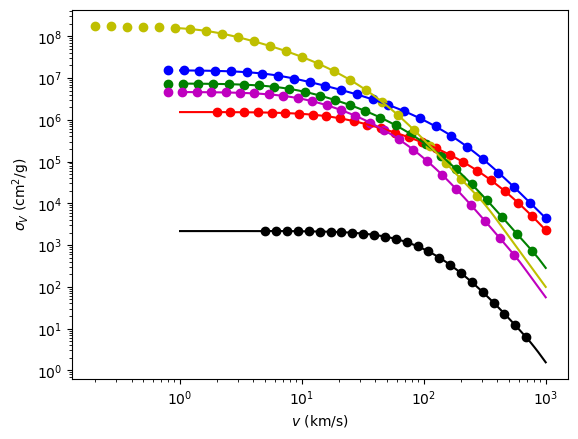

In [3]:
log10_mass_ratio_plot = [3.6, 4.0, 4.4, 4.4, 4.4, 5.0]
log10_alpha_plot = [-4.1, -2.6, -2.6, -3.2, -3.5, -3.5]
v_extended = np.logspace(0, 3, 100)
cols = ['k', 'r', 'b', 'g', 'm', 'y']
for i, (log10_mass_ratio, log10_alpha) in enumerate(zip(log10_mass_ratio_plot, log10_alpha_plot)):
    v_grid, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
    cross = CrossSection.from_phase_shifts(
        v_grid, phases, 'VISCOSITY', log10_alpha, log10_mass_ratio
    )
    v_lin = 10 ** v_grid
    sigma_exact = cross(v_lin, None)
    
    plt.scatter(v_lin, sigma_exact, color=cols[i])
    plt.loglog(v_extended, cross_section_interpolator(v_extended, None, log10_alpha, log10_mass_ratio),
              color=cols[i])
    
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

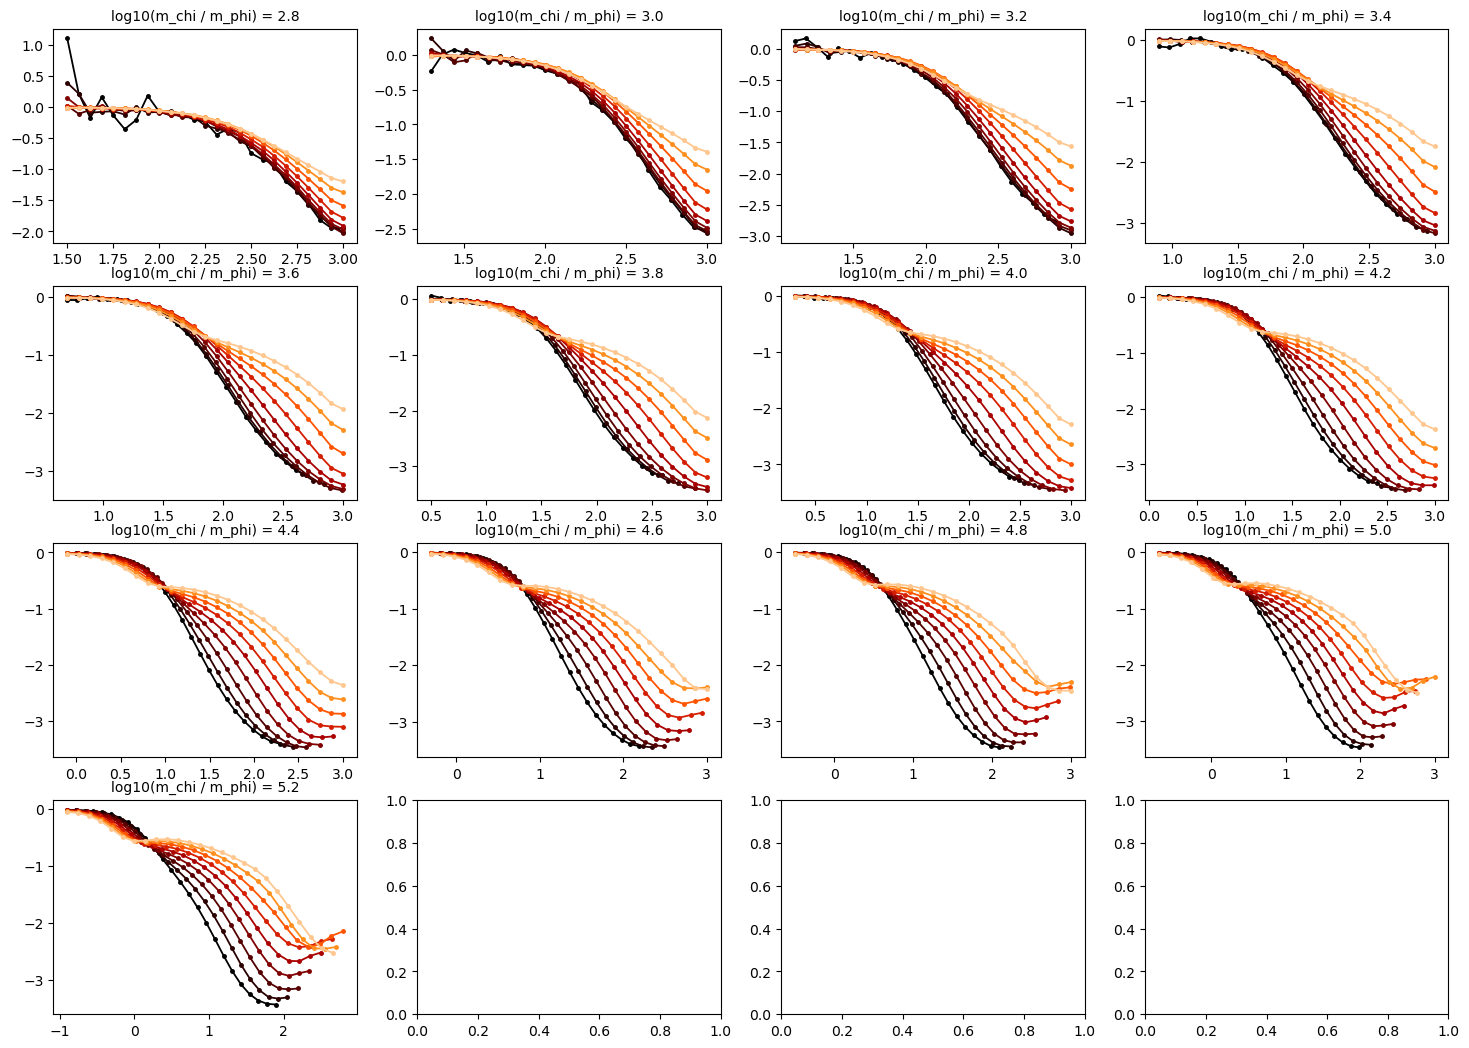

In [4]:
log10_mass_ratio_plot = np.arange(2.8, 5.2, 0.2)
log10_alpha_plot = np.arange(-4.4, -2.0, 0.3)

ncols = 4
nrows = int(np.ceil(len(log10_mass_ratio_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                             figsize=(18, nrows * 3.2),
                             sharey=False)
axes = axes.flatten()
cmap = plt.get_cmap('gist_heat')
alpha_colours = [cmap(i/len(log10_alpha_plot)) for i in range(0, len(log10_alpha_plot))]

for idx, log10_mr in enumerate(log10_mass_ratio_plot):
    ax = axes[idx]
    ax.set_title('log10(m_chi / m_phi) = '+str(np.round(log10_mr,2)), fontsize=10)
    for idx_alpha, log10a in enumerate(log10_alpha_plot):
        log10v_grid, phases = get_phases(log10_mr, log10a, 'REPULSIVE_YUKAWA')
        cross = CrossSection.from_phase_shifts(
            log10v_grid, phases, 'VISCOSITY', log10a, log10_mr
                )
        sigmav = cross(10**log10v_grid, None)
        slope = np.gradient(np.log(sigmav), np.log(10**log10v_grid))
        ax.plot(log10v_grid, slope, '-o',
                    markersize=2.5, linewidth=1.3,
                    color=alpha_colours[idx_alpha])
    

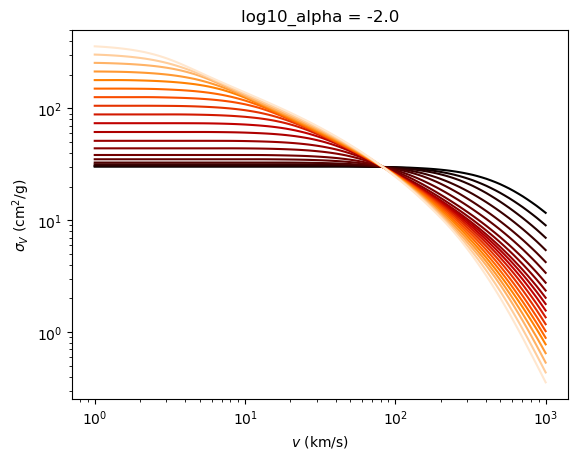

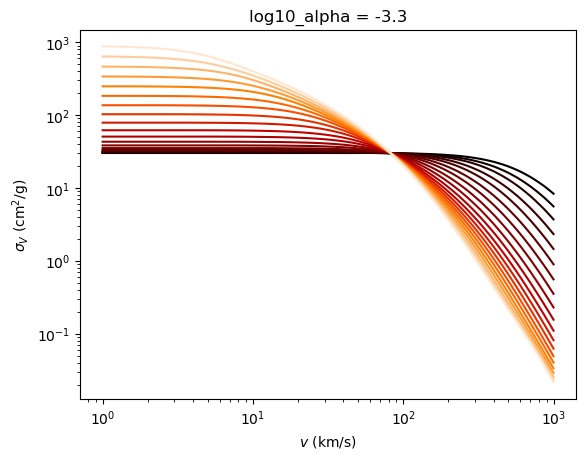

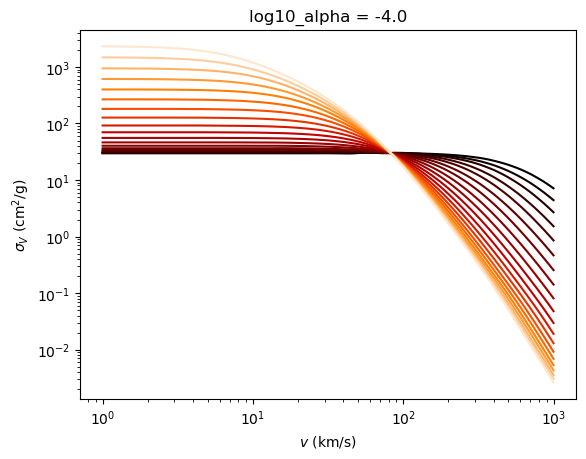

In [10]:
log10_mass_ratio_plot = np.linspace(3, 5, 20)
log10_alpha = -2.
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v_extended, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

log10_mass_ratio_plot = np.linspace(3, 5, 20)
log10_alpha = -3.3
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v_extended, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

log10_mass_ratio_plot = np.linspace(3, 5, 20)
log10_alpha = -4.0
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v_extended, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()